# **Search for Higgs Bosons in the $H \to ZZ \to 2\ell2q$ Channel**

## Code Preliminaries

In [1]:
# Load Packages
!pip install mplhep
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import mplhep as hep
plt.style.use(hep.style.CMS)
from google.colab import drive
drive.mount('/content/drive')
from typing import Optional
import os
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load the data
dir = "/content/drive/MyDrive/ExP-CMS/Data/"

ZJets = pd.read_csv(dir+'ZJets.csv')
Higgs350 = pd.read_csv(dir+'Higgs2L2Q_M350.csv')
Higgs400 = pd.read_csv(dir+'Higgs2L2Q_M400.csv')
Higgs500 = pd.read_csv(dir+'Higgs2L2Q_M500.csv')
Data = pd.read_csv(dir+'Real-Data.csv')

# Define luminosities
lumi_data = 19.7
lumi_zjets = 33.4
lumi_higgs350 = 305.0
lumi_higgs400 = 541.0
lumi_higgs500 = 1271.0

### Functions & Functionality

``plot_cms``

In [3]:
# ── Default CMS-style colour palettes ────────────────────────────────────────
_BKG_COLORS = [
    "#3182bd", "#e6550d", "#31a354", "#756bb1",
    "#636363", "#6baed6", "#fd8d3c", "#74c476",
]
_SIG_COLORS = ["#e41a1c", "#ff7f00", "#984ea3", "#a65628"]


def plot_cms(
    df,
    var: str,
    x_range: tuple[float, float],
    bins: int,
    xl: Optional[str] = None,
    log: bool = False,
    ylim: Optional[tuple[float, float]] = None,
    mc: Optional[dict] = None,
    lumi_data: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    ratio: bool = True,
    figsize: Optional[tuple[float, float]] = None,
    yl: str = "Events",
    year: Optional[str] = None,
) -> tuple:
    """
    Produce a CMS-official style histogram.

    Parameters
    ----------
    df : pd.DataFrame
        Observed data.
    var : str
        Column name to histogram.
    x_range : (float, float)
        (x_min, x_max) of the histogram range.
    bins : int
        Number of equal-width bins.
    xl : str, optional
        X-axis label. Defaults to ``var``.
    log : bool
        Use a logarithmic y-axis.
    ylim : (float, float), optional
        Override y-axis limits (useful to leave room for the legend).
    mc : dict, optional
        Monte Carlo processes. Each entry has the form::

            mc = {
                "key": {
                    "df"    : pd.DataFrame,   # required
                    "label" : str,            # required  – legend text
                    "lumi"  : float,          # required  – MC lumi in fb⁻¹
                    "type"  : "bkg" | "sig",  # optional, default "bkg"
                    "color" : str,            # optional  – auto-assigned otherwise
                },
                ...
            }

        Backgrounds are drawn as a **stacked** filled histogram; signals as
        **step** (outline-only) histograms on top.
    lumi_data : float, optional
        Integrated luminosity of the data sample in fb⁻¹.
        Used for MC normalisation (scale = lumi_data / lumi_mc) and the
        header label.
    cms_label : str
        Text next to the CMS logo ("Preliminary", "Work in Progress", etc.).
    com : float
        Centre-of-mass energy in TeV.
    ratio : bool
        Draw a Data / MC ratio panel below the main plot (requires backgrounds).
    figsize : (float, float), optional
        Override figure size. Sensible defaults are chosen automatically.
    yl : str
        Y-axis label (default ``"Events"``).
    year : str, optional
        Data-taking year shown in the header (e.g. ``"2018"``).

    Returns
    -------
    (fig, ax)            when ``ratio=False`` or no backgrounds are present.
    (fig, ax, ax_ratio)  when a ratio panel is drawn.
    """
    hep.style.use("CMS")

    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    xl = xl or var

    # ── Parse MC entries ──────────────────────────────────────────────────────
    bkg_entries, sig_entries = [], []
    n_bkg = n_sig = 0

    if mc:
        for key, info in mc.items():
            entry = {**info}  # shallow copy – don't mutate the caller's dict
            etype = entry.get("type", "bkg")

            if "color" not in entry:
                if etype == "bkg":
                    entry["color"] = _BKG_COLORS[n_bkg % len(_BKG_COLORS)]
                else:
                    entry["color"] = _SIG_COLORS[n_sig % len(_SIG_COLORS)]

            scale = (lumi_data / entry["lumi"]) if (lumi_data and entry.get("lumi")) else 1.0
            raw, _ = np.histogram(entry["df"][var], bins=bin_edges)
            entry["counts"] = raw * scale
            entry["errors"] = np.sqrt(raw) * scale
            entry["weights"] = np.full(len(entry["df"]), scale)

            if etype == "bkg":
                bkg_entries.append(entry)
                n_bkg += 1
            else:
                sig_entries.append(entry)
                n_sig += 1

    # ── Data ──────────────────────────────────────────────────────────────────
    counts_data, _ = np.histogram(df[var], bins=bin_edges)
    errors_data    = np.sqrt(counts_data)

    # ── Total background for ratio / uncertainty band ─────────────────────────
    has_bkg = bool(bkg_entries)
    if has_bkg:
        total_bkg     = np.sum([e["counts"] for e in bkg_entries], axis=0)
        total_bkg_err = np.sqrt(np.sum([e["errors"] ** 2 for e in bkg_entries], axis=0))

    show_ratio = ratio and has_bkg

    # ── Figure layout ─────────────────────────────────────────────────────────
    if figsize is None:
        figsize = (10, 11) if show_ratio else (10, 8)

    if show_ratio:
        fig, (ax, ax_ratio) = plt.subplots(
            2, 1,
            figsize=figsize,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
            sharex=True,
        )
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_ratio = None

    # ── Stacked backgrounds ───────────────────────────────────────────────────
    if has_bkg:
        ax.hist(
            [e["df"][var] for e in bkg_entries],
            bins=bin_edges,
            weights=[e["weights"] for e in bkg_entries],
            stacked=True,
            histtype="stepfilled",
            color=[e["color"] for e in bkg_entries],
            label=[e["label"] for e in bkg_entries],
            linewidth=0.6,
            edgecolor="black",
        )

        # Hatched statistical-uncertainty band on the total background
        ax.bar(
            bin_centers,
            2 * total_bkg_err,
            bottom=total_bkg - total_bkg_err,
            width=bin_width,
            fill=False,
            edgecolor="dimgrey",
            hatch="////",
            linewidth=0,
            label="Stat. Unc.",
            zorder=3,
        )

    # ── Signal histograms (step lines) ────────────────────────────────────────
    for entry in sig_entries:
        ax.hist(
            entry["df"][var],
            bins=bin_edges,
            weights=entry["weights"],
            histtype="step",
            color=entry["color"],
            label=entry["label"],
            linewidth=2.2,
        )

    # ── Data points ───────────────────────────────────────────────────────────
    ax.errorbar(
        bin_centers,
        counts_data,
        yerr=errors_data,
        fmt="o",
        color="black",
        markersize=5,
        capsize=3,
        elinewidth=1.3,
        label="Data",
        zorder=5,
    )

    # ── CMS header ────────────────────────────────────────────────────────────
    hep.cms.label(
        cms_label,
        data=True,
        lumi=lumi_data,
        com=com,
        year=year,
        ax=ax,
    )

    # ── Main-panel cosmetics ──────────────────────────────────────────────────
    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.legend(loc="upper right", frameon=False, ncols=2 if (n_bkg + n_sig) > 4 else 1)
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    if not show_ratio:
        ax.set_xlabel(xl, ha="right", x=1.0)

    # ── Ratio panel ───────────────────────────────────────────────────────────
    if show_ratio:
        safe = total_bkg > 0

        ratio_vals    = np.where(safe, counts_data / total_bkg,     np.nan)
        ratio_err     = np.where(safe, errors_data / total_bkg,     np.nan)
        rel_bkg_err   = np.where(safe, total_bkg_err / total_bkg,   np.nan)

        # Shaded MC uncertainty band centred on 1
        ax_ratio.bar(
            bin_centers,
            2 * rel_bkg_err,
            bottom=1.0 - rel_bkg_err,
            width=bin_width,
            color="dimgrey",
            alpha=0.35,
            linewidth=0,
        )

        ax_ratio.errorbar(
            bin_centers,
            ratio_vals,
            yerr=ratio_err,
            fmt="o",
            color="black",
            markersize=5,
            capsize=3,
            elinewidth=1.3,
        )

        ax_ratio.axhline(1.0, color="black", linewidth=0.9, linestyle="--")

        ax_ratio.set_xlabel(xl, ha="right", x=1.0)
        ax_ratio.set_ylabel(r"$\frac{\mathrm{Data}}{\mathrm{MC}}$", fontsize=14)
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.yaxis.set_major_locator(ticker.FixedLocator([0.5, 0.75, 1.0, 1.25, 1.5]))
        ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_ratio.set_xlim(*x_range)

    fig.align_ylabels()

    if show_ratio:
        return fig, ax, ax_ratio
    return fig, ax

``compare_cms``

In [4]:
# ── Default comparison colour cycle (qualitative, colour-blind friendly) ──────
_CMP_COLORS = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # grey
]

def compare_cms(
    var: str,
    datasets: dict,
    x_range: tuple[float, float],
    bins: int,
    xl: Optional[str] = None,
    yl: Optional[str] = None,
    density: bool = True,
    log: bool = False,
    lumi_ref: Optional[float] = None,
    cms_label: str = "Preliminary",
    com: float = 13,
    figsize: Optional[tuple[float, float]] = None,
    ylim: Optional[tuple[float, float]] = None,
    year: Optional[str] = None,
) -> tuple[plt.Figure, plt.Axes]:
    hep.style.use("CMS")
    """
    CMS-style shape-comparison plot.

    Draws each MC process as a step histogram and each data sample as error-bar
    points.  Designed for cut optimisation, MC validation, and variable studies.

    Parameters
    ----------
    var : str
        Column name to histogram.
    datasets : dict
        One entry per sample.  Each value is a dict with the following keys::

            datasets = {
                "key": {
                    "df"    : pd.DataFrame,   # required
                    "label" : str,            # required  – legend text
                    "lumi"  : float,          # optional  – MC lumi in fb⁻¹
                                              #   (needed only for density=False)
                    "type"  : "mc" | "data",  # optional, default "mc"
                    "color" : str,            # optional  – auto-assigned otherwise
                },
                ...
            }

    x_range : (float, float)
        (x_min, x_max) of the histogram range.
    bins : int
        Number of equal-width bins.
    xl : str, optional
        X-axis label.  Defaults to ``var``.
    yl : str, optional
        Y-axis label.  Defaults to ``"Density"`` or ``"Events"``
        depending on ``density``.
    density : bool
        Normalise each histogram to unit area so that only shapes are compared.
        When ``False``, histograms are scaled to ``lumi_ref`` (if provided).
    log : bool
        Logarithmic y-axis.
    lumi_ref : float, optional
        Reference luminosity in fb⁻¹.  Used for:
        * MC event-count scaling when ``density=False``
          (scale = lumi_ref / lumi_mc).
        * The luminosity shown in the CMS header.
    cms_label : str
        Text next to the CMS logo.  Default ``"Preliminary"``.
    com : float
        Centre-of-mass energy in TeV.
    figsize : (float, float), optional
        Override the default ``(10, 8)`` figure size.
    ylim : (float, float), optional
        Override y-axis limits.
    year : str, optional
        Data-taking year shown in the header.

    Returns
    -------
    (fig, ax)

    Notes
    -----
    * In ``density=True`` mode luminosity weights cancel in the normalisation,
      so ``lumi_ref`` / ``lumi`` have no effect on the shapes drawn—only on the
      header label.
    * Poisson errors on data points are propagated as
      ``σ_density = √N_i / (N_total · Δx)`` per bin.
    """
    # ── Binning ───────────────────────────────────────────────────────────────
    bin_edges   = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]
    xl = xl or var

    # ── Parse entries ─────────────────────────────────────────────────────────
    mc_entries, data_entries = [], []
    has_data = False
    color_idx = 0

    for key, info in datasets.items():
        entry = {**info}
        etype = entry.get("type", "mc")

        if etype == "data":
            entry["color"] = entry.get("color", "black")  # black by default, overridable
        else:
            if "color" not in entry:
                entry["color"] = _CMP_COLORS[color_idx % len(_CMP_COLORS)]
            color_idx += 1  # only advance the MC palette for MC entries

        raw_counts, _ = np.histogram(entry["df"][var], bins=bin_edges)

        if etype == "data":
            has_data = True
            n_total = raw_counts.sum()
            if density and n_total > 0:
                entry["vals"] = raw_counts / (n_total * bin_width)
                entry["errs"] = np.sqrt(raw_counts) / (n_total * bin_width)
            else:
                entry["vals"] = raw_counts.astype(float)
                entry["errs"] = np.sqrt(raw_counts.astype(float))
            data_entries.append(entry)

        else:
            if density:
                entry["weights"] = np.ones(len(entry["df"]))
                entry["density"] = True
            else:
                scale = (lumi_ref / entry["lumi"]) if (lumi_ref and entry.get("lumi")) else 1.0
                entry["weights"] = np.full(len(entry["df"]), scale)
                entry["density"] = False
            mc_entries.append(entry)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize or (10, 8))

    # ── MC step histograms ────────────────────────────────────────────────────
    for entry in mc_entries:
        ax.hist(
            entry["df"][var],
            bins=bin_edges,
            weights=entry["weights"],
            density=entry["density"],
            histtype="step",
            color=entry["color"],
            label=entry["label"],
            linewidth=2.0,
        )

    # ── Data error-bar points ─────────────────────────────────────────────────
    for entry in data_entries:
        ax.errorbar(
            bin_centers,
            entry["vals"],
            yerr=entry["errs"],
            fmt="o",
            color=entry["color"],
            markersize=5,
            capsize=3,
            elinewidth=1.3,
            label=entry["label"],
            zorder=5,
        )

    # ── CMS header ────────────────────────────────────────────────────────────
    hep.cms.label(
        cms_label,
        data=has_data,
        lumi=lumi_ref if has_data else None,
        com=com,
        year=year,
        ax=ax,
    )

    # ── Cosmetics ─────────────────────────────────────────────────────────────
    if yl is None:
        yl = "Density" if density else "Events"

    ax.set_ylabel(yl, ha="right", y=1.0)
    ax.set_xlabel(xl, ha="right", x=1.0)
    ax.legend(loc="upper right", frameon=False)
    ax.set_xlim(*x_range)

    if log:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(ylim)
    elif not log:
        ax.set_ylim(bottom=0)

    return fig, ax

``kinematic_to_cartesian`` & ``calculate_invariant_mass`` & ``calculate_invariant_mass_four_particles``

In [15]:
def kinematic_to_cartesian(df, prefix):
    # Particle 1
    pt1 = df[f'pt{prefix}1']
    eta1 = df[f'eta{prefix}1']
    phi1 = df[f'phi{prefix}1']
    e1 = df[f'e{prefix}1']

    df[f'px{prefix}1'] = pt1 * np.cos(phi1)
    df[f'py{prefix}1'] = pt1 * np.sin(phi1)
    df[f'pz{prefix}1'] = pt1 * np.sinh(eta1)
    df[f'E{prefix}1'] = e1

    # Particle 2
    pt2 = df[f'pt{prefix}2']
    eta2 = df[f'eta{prefix}2']
    phi2 = df[f'phi{prefix}2']
    e2 = df[f'e{prefix}2']

    df[f'px{prefix}2'] = pt2 * np.cos(phi2)
    df[f'py{prefix}2'] = pt2 * np.sin(phi2)
    df[f'pz{prefix}2'] = pt2 * np.sinh(eta2)
    df[f'E{prefix}2'] = e2

    return df

def calculate_invariant_mass(E1, px1, py1, pz1, E2, px2, py2, pz2):
    sum_E = E1 + E2
    sum_px = px1 + px2
    sum_py = py1 + py2
    sum_pz = pz1 + pz2
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

def calculate_invariant_mass_four_particles(E1, px1, py1, pz1, E2, px2, py2, pz2, E3, px3, py3, pz3, E4, px4, py4, pz4):
    sum_E = E1 + E2 + E3 + E4
    sum_px = px1 + px2 + px3 + px4
    sum_py = py1 + py2 + py3 + py4
    sum_pz = pz1 + pz2 + pz3 + pz4
    return np.sqrt(sum_E**2 - (sum_px**2 + sum_py**2 + sum_pz**2))

# List of dataframes to process
df_list = [ZJets, Higgs350, Higgs400, Higgs500, Data]
df_names = ['ZJets', 'Higgs350', 'Higgs400', 'Higgs500', 'Data']

for i, df in enumerate(df_list):
    # Convert lepton kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'l')

    # Convert jet kinematic variables to Cartesian coordinates
    df = kinematic_to_cartesian(df, 'j')

    # Calculate Mll (dilepton invariant mass)
    df['Mll'] = calculate_invariant_mass(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'])

    # Calculate Mjj (dijet invariant mass)
    df['Mjj'] = calculate_invariant_mass(df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    # Calculate Mlljj (total invariant mass of the 2-lepton, 2-jet system)
    df['Mlljj'] = calculate_invariant_mass_four_particles(df['El1'], df['pxl1'], df['pyl1'], df['pzl1'],
                                                        df['El2'], df['pxl2'], df['pyl2'], df['pzl2'],
                                                        df['Ej1'], df['pxj1'], df['pyj1'], df['pzj1'],
                                                        df['Ej2'], df['pxj2'], df['pyj2'], df['pzj2'])

    df_list[i] = df # Update the dataframe in the list

    print(f"Updated {df_names[i]} with Cartesian coordinates and invariant masses.")
    #display(df.head())

# Reassign the modified dataframes back to their original names
ZJets, Higgs350, Higgs400, Higgs500, Data = df_list

Updated ZJets with Cartesian coordinates and invariant masses.
Updated Higgs350 with Cartesian coordinates and invariant masses.
Updated Higgs400 with Cartesian coordinates and invariant masses.
Updated Higgs500 with Cartesian coordinates and invariant masses.
Updated Data with Cartesian coordinates and invariant masses.


``find_cut``

In [ ]:
def find_cut(sgn, bkg, var, lumi_sgn, lumi_bkg, lumi_data, n_scan=500, minN=10):
    # Arrays with the values
    s_vals_raw = sgn[var].values
    b_vals_raw = bkg[var].values

    # Calculate luminosity weights
    weight_sgn = lumi_data / lumi_sgn
    weight_bkg = lumi_data / lumi_bkg

    # Total number of events scaled by luminosity
    N_S_total_scaled = len(s_vals_raw) * weight_sgn
    N_B_total_scaled = len(b_vals_raw) * weight_bkg

    # Find the limits of values
    lo = min(s_vals_raw.min(), b_vals_raw.min())
    hi = max(s_vals_raw.max(), b_vals_raw.max())

    # Scan over the combined range of both distributions
    cuts = np.linspace(lo, hi, n_scan)
    S_values = np.full(n_scan, np.nan)
    S_scaled_values = np.full(n_scan, np.nan)

    for i, X in enumerate(cuts):
        # Number of events passing the cut, scaled by luminosity
        N_S_cut_scaled = np.sum(s_vals_raw > X) * weight_sgn
        N_B_cut_scaled = np.sum(b_vals_raw > X) * weight_bkg

        if (N_S_cut_scaled + N_B_cut_scaled) >= minN:
            S_scaled_values[i] = N_S_cut_scaled / np.sqrt(10*N_S_cut_scaled + N_B_cut_scaled)
        if N_B_cut_scaled > 0:
            S_values[i] = N_S_cut_scaled / np.sqrt(N_B_cut_scaled)

    best_idx = np.nanargmax(S_scaled_values)
    best_cut = cuts[best_idx]

    # Calculate values for the returned dictionary using scaled counts
    total_significance = N_S_total_scaled / np.sqrt(N_B_total_scaled)
    scaled_significance_at_best_cut = S_scaled_values[best_idx]
    significance_at_best_cut = S_values[best_idx]

    # Efficiencies should be based on raw (unscaled) event counts as they represent acceptance
    eff_signal = np.sum(s_vals_raw > best_cut) / len(s_vals_raw)
    eff_bkg = np.sum(b_vals_raw > best_cut) / len(b_vals_raw)

    return {
        "best_cut": best_cut,
        "total_significance": total_significance,
        "scaled_significance": scaled_significance_at_best_cut,
        "significance": significance_at_best_cut,
        "cuts": cuts,
        "S_scaled_values": S_scaled_values,
        "S_values": S_values,
        "eff_signal": eff_signal,
        "eff_bkg": eff_bkg
    }

def plot_cut(sgn, bkg, var, result, x_range=None, xl=None):
    s_vals  = sgn[var].values
    b_vals  = bkg[var].values
    X_best  = result["best_cut"]

    if x_range:
        bins = np.linspace(x_range[0], x_range[1], 70)
    else:
        bins = np.linspace(min(s_vals.min(), b_vals.min()),
                          max(s_vals.max(), b_vals.max()), 60)

    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(19, 8))
    fig.tight_layout(w_pad=3)

    # Plot 1: Distributions
    ax1.hist(b_vals, bins=bins, density=True,
             color="r", label="Background", histtype='step', linewidth=1.5)
    ax1.hist(s_vals, bins=bins, density=True,
             color="b", label="Signal", histtype='step', linewidth=1.5)
    ax1.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}")

    hep.cms.label("Preliminary", data=False, lumi=lumi_data, com=8, ax=ax1)

    ylim = ax1.get_ylim()

    ax1.set_xlabel(xl if xl else var)
    ax1.set_ylabel("Density")
    ax1.legend()
    ax1.set_ylim(ylim)
    # Plot 2: Significance curve
    ax2.plot(result["cuts"], result["S_scaled_values"],
             color="m", lw=1.5, label=r"$N_S\,/\,\sqrt{10 N_S + N_B}$")
    ax2.plot(result["cuts"], result["S_values"],
             color="orange", lw=1.5, ls='-.', label=r"$N_S\,/\,\sqrt{N_B}$")
    ax2.axvline(X_best, color="k", lw=1.5, ls="--",
                label=f"X = {X_best:.3f}\n"
                      f"$R_S$ = {result['significance']/result['total_significance']:.2f}\n"
                      f"$ε_{{sig}}$ = {result['eff_signal']:.1%}\n"
                      f"$ε_{{bkg}}$ = {result['eff_bkg']:.1%}")
    #ax2.scatter([X_best], [result["scaled_significance"]],color="k", zorder=5, s=50)
    ax2.set_xlabel(xl if xl else var,)
    ax2.set_ylabel(r"Significance")
    ax2.legend()

    hep.cms.label("Preliminary", data=False, lumi=lumi_data, com=8, ax=ax2)

    if x_range:
        ax2.set_xlim(x_range)

    plt.show()

## Essential Cuts



*   $-2.5\leq\eta\leq2.5$
*   $60\,\text{GeV} \leq M_{jj} \leq 130 \,\text{GeV}$
*   



In [16]:
# Print columns of data
Data.columns

Index(['ptl1', 'etal1', 'phil1', 'el1', 'ptl2', 'etal2', 'phil2', 'el2',
       'ptj1', 'etaj1', 'phij1', 'ej1', 'ptj2', 'etaj2', 'phij2', 'ej2', 'ld',
       'pxl1', 'pyl1', 'pzl1', 'El1', 'pxl2', 'pyl2', 'pzl2', 'El2', 'pxj1',
       'pyj1', 'pzj1', 'Ej1', 'pxj2', 'pyj2', 'pzj2', 'Ej2', 'Mll', 'Mjj',
       'Mlljj'],
      dtype='object')

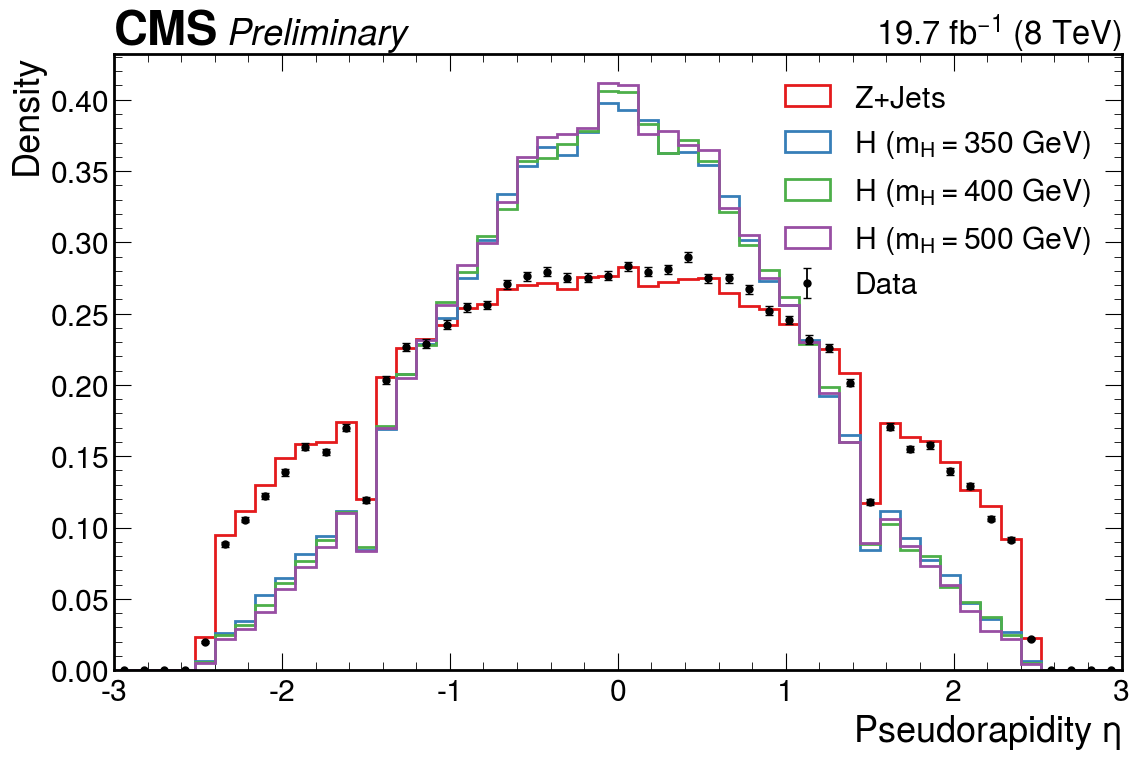

In [40]:
fig, ax = compare_cms(
    var      = "etal1",
    datasets = {
        "ZJets"    : {"df": ZJets,    "label": r"$Z$+Jets",                       "lumi": lumi_zjets},
        "Higgs350" : {"df": Higgs350, "label": r"$H\ (m_H = 350\ \mathrm{GeV})$", "lumi": lumi_higgs350},
        "Higgs400" : {"df": Higgs400, "label": r"$H\ (m_H = 400\ \mathrm{GeV})$", "lumi": lumi_higgs400},
        "Higgs500" : {"df": Higgs500, "label": r"$H\ (m_H = 500\ \mathrm{GeV})$", "lumi": lumi_higgs500},
        "Data"     : {"df": Data,     "label": "Data",                            "type": "data"},
    },
    x_range  = (-3, 3),
    figsize  = (13,8),
    bins     = 50,
    xl       = r"Pseudorapidity $\eta$",
    density  = True,
    lumi_ref = lumi_data,
    com      = 8,
    cms_label= "Preliminary",
)

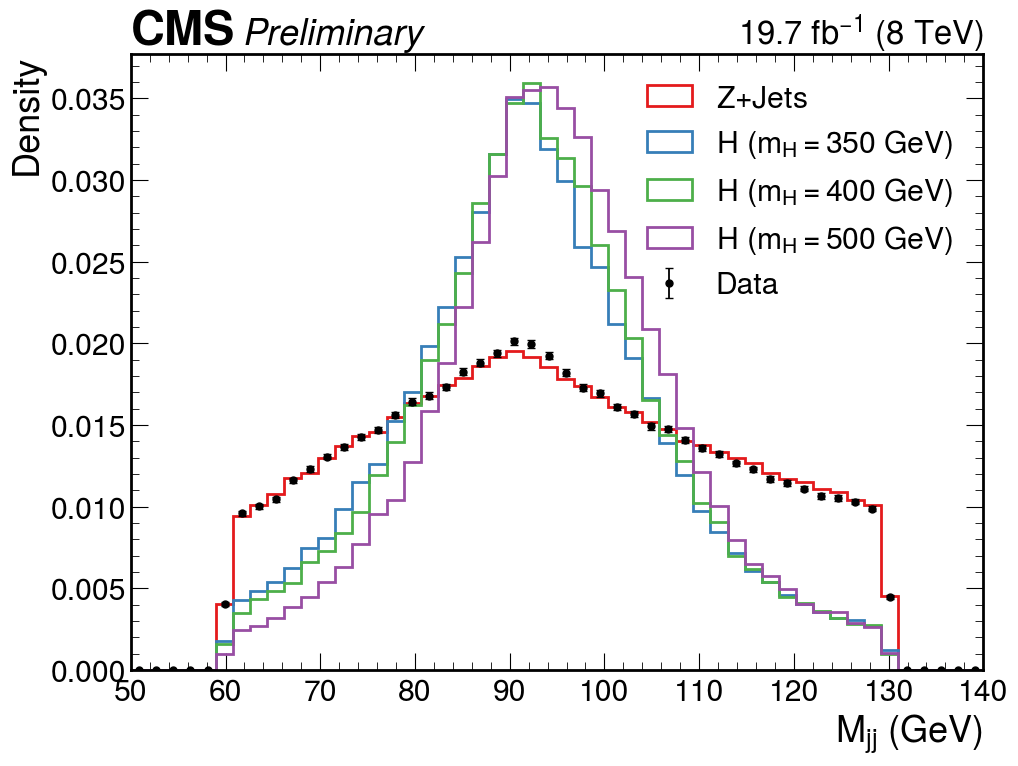

In [42]:
fig, ax = compare_cms(
    var      = "Mjj",
    datasets = {
        "ZJets"    : {"df": ZJets,    "label": r"$Z$+Jets",                       "lumi": lumi_zjets},
        "Higgs350" : {"df": Higgs350, "label": r"$H\ (m_H = 350\ \mathrm{GeV})$", "lumi": lumi_higgs350},
        "Higgs400" : {"df": Higgs400, "label": r"$H\ (m_H = 400\ \mathrm{GeV})$", "lumi": lumi_higgs400},
        "Higgs500" : {"df": Higgs500, "label": r"$H\ (m_H = 500\ \mathrm{GeV})$", "lumi": lumi_higgs500},
        "Data"     : {"df": Data,     "label": "Data",                            "type": "data"},
    },
    x_range  = (50, 140),
    figsize  = (11,8),
    bins     = 50,
    xl       = r"$M_{jj}$ (GeV)",
    density  = True,
    lumi_ref = lumi_data,
    com      = 8,
    cms_label= "Preliminary",
)

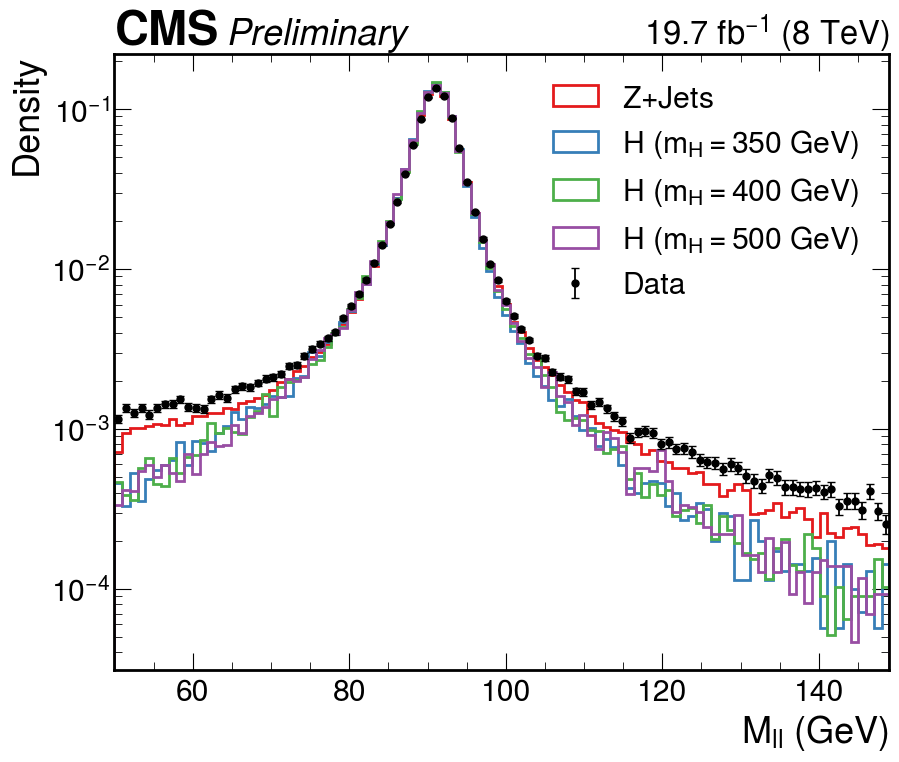

In [47]:
fig, ax = compare_cms(
    var      = "Mll",
    datasets = {
        "ZJets"    : {"df": ZJets,    "label": r"$Z$+Jets",                       "lumi": lumi_zjets},
        "Higgs350" : {"df": Higgs350, "label": r"$H\ (m_H = 350\ \mathrm{GeV})$", "lumi": lumi_higgs350},
        "Higgs400" : {"df": Higgs400, "label": r"$H\ (m_H = 400\ \mathrm{GeV})$", "lumi": lumi_higgs400},
        "Higgs500" : {"df": Higgs500, "label": r"$H\ (m_H = 500\ \mathrm{GeV})$", "lumi": lumi_higgs500},
        "Data"     : {"df": Data,     "label": "Data",                            "type": "data"},
    },
    x_range  = (50, 149),
    #figsize  = (11,8),
    bins     = 100,
    xl       = r"$M_{ll}$ (GeV)",
    density  = True,
    log      = True,
    lumi_ref = lumi_data,
    com      = 8,
    cms_label= "Preliminary",
)